Here, we confirm that Basal cells are most strongly effected by TGFB1 as stated by [McCauley](https://linkinghub.elsevier.com/retrieve/pii/S2405471224000590)

In [22]:
import os
from contextlib import contextmanager
from collections import defaultdict
import copy
import warnings
import sys
import math

from tqdm import trange, tqdm

import numpy as np
import pandas as pd
import torch

from scipy.spatial.distance import mahalanobis
from scipy.linalg import inv
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

import sys
sys.path.insert(1, '../../.')
from McCauley_utils import all_data, initialize_mod_and_trainer

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split, clear_adata

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls
from scLEMBAS.predict import get_prediction

In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)

In [3]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data


In [4]:
@contextmanager
def suppress_all_output():
    """
    Suppress stdout, stderr, warnings, tqdm, and most parallel chatter.
    """
    # save originals
    old_stdout = sys.stdout
    old_stderr = sys.stderr

    try:
        # redirect stdout / stderr
        sys.stdout = open(os.devnull, 'w')
        sys.stderr = open(os.devnull, 'w')

        # silence warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            # silence tqdm globally
            os.environ["TQDM_DISABLE"] = "1"

            yield

    finally:
        # restore
        sys.stdout.close()
        sys.stderr.close()
        sys.stdout = old_stdout
        sys.stderr = old_stderr

        os.environ.pop("TQDM_DISABLE", None)

In [5]:
# as in Notebook 04
csw = {
    'max_components': 25 ,
    'metric': 'accuracy', 
    'method': 'elbow', 
    'n_folds': 5, 
    'seed': 888
}

assessment_kwargs = {
    'n_perm': 100, 
    'get_q2_pval': True, 
    'get_r2_pval': False, 
    'get_accuracy_pval': False,
    'n_folds': 5, 
    'seed': 888
}


In [6]:
pert_mask = tf_adata.obs[pert_col].isin([ctrl_pert, 'TGFB1'])
tf_adata_sub = tf_adata[pert_mask].copy()

ct_include = []
for ct in tf_adata_sub.obs[cat_col].unique():
    cat_mask = tf_adata_sub.obs[cat_col] == ct
    if tf_adata_sub[cat_mask].obs[pert_col].nunique() != 2:
        print('The cell type {} does not have both control and TGFB1, will not be considered downstream'.format(ct))
    else:
        ct_include.append(ct)
        
cat_mask = tf_adata_sub.obs[cat_col].isin(ct_include)
tf_adata_sub = tf_adata_sub[cat_mask].copy()

The cell type Goblet does not have both control and TGFB1, will not be considered downstream


In [7]:
with suppress_all_output():
    models, X_pls = ls.pls_da(
        adata = tf_adata_sub, 
        n_components = None, 
        assess = True, 
        enc_X = None, enc_Y = None, control_confounders = None, 
        separate_by =  'perturbation', #'both', 
        pert_col = pert_col, 
        cat_col = cat_col, 
        component_selection_kwargs = csw, 
        assessment_kwargs = assessment_kwargs, 
        n_cores = n_cores, 
        verbose = False
    )

pls_model = models['pls_model']

X_pls = pd.DataFrame(X_pls, 
                    columns = ['PLS{}'.format(i + 1) for i in range(pls_model.n_components)])
X_pls[cat_col] = tf_adata_sub.obs[cat_col].tolist()
X_pls[pert_col] = tf_adata_sub.obs[pert_col].tolist()
X_pls_actual = X_pls.copy()
X_pls_actual['mod_id'] = 'actual'

''

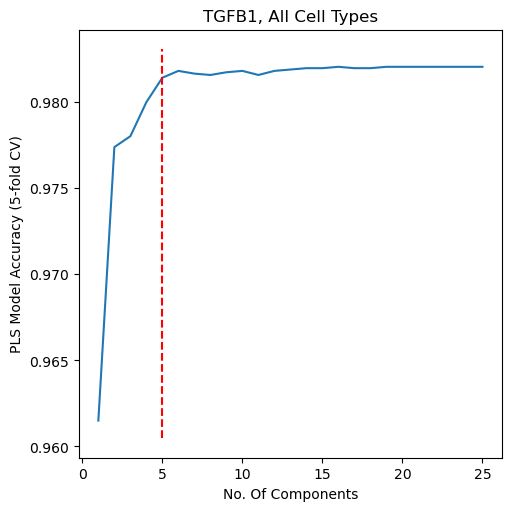

In [8]:
fig, ax = plt.subplots(figsize = (5, 5), constrained_layout = True)

n_components = pls_model.n_components
q2y = pls_model.assessment_metrics['Q2Y']['value']
q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']

sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax)
ymin, ymax = ax.get_ylim()
ax.vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
          color = 'red', linestyle = '--'
         )
ax.set_xlabel('No. Of Components')
ax.set_ylabel('PLS Model Accuracy (5-fold CV)')
ax.set_title('TGFB1, All Cell Types')
;

# Get Predictions

When combining with subnetwork analysis, will need to do this for ensembles instead of just the primary models.

In [9]:
# def load_model(fold, from_trainer = False):
#     """Loads the model and training object.

#     Two different ways to do so: from pickled training object (larger files) or from model state dict `.pt` file (smaller files to transfer).

#     Parameters
#     ----------
#     fold : int
#         fold split
#     ensemble_idx : int
#         ensemble index
#     from_trainer : bool, optional
#         whether to load from trainer object or model state dict, by default False
#         if False, the training object is not returned
#     """
#     fn_base = os.path.join(data_path, 'processed', '{}_fold{}'.format(author, fold))
#     if from_trainer:
#         fn_trainer = os.path.join(fn_base + 'trainer_actual.pickle')
#         trainer = io.read_pickled_object(fn_trainer)
#         mod = trainer.mod
#     else:
#         mod, trainer = initialize_mod_and_trainer(
#             fold = fold, 
#             adversarial_penalty = True, 
#             randomize = False, 
#             seed = seed
#         )
#         fn_mod = os.path.join(fn_base + 'model_actual.pt')
            
#         mod.load_state_dict(torch.load(fn_mod))
#         trainer = None
#     return mod, trainer


n_ensembles = 10
seed_multiplier = 21234
def load_model(fold, ensemble_idx, from_trainer = False):
    """Loads the model and training object.

    Two different ways to do so: from pickled training object (larger files) or from model state dict `.pt` file (smaller files to transfer).

    Parameters
    ----------
    fold : int
        fold split
    ensemble_idx : int
        ensemble index
    from_trainer : bool, optional
        whether to load from trainer object or model state dict, by default False
        if False, the training object is not returned
    """
    fn_base = os.path.join(data_path, 'processed', '{}_fold{}'.format(author, fold))
    if from_trainer:
        if ensemble_idx <= 3:
            fn_trainer =  os.path.join(fn_base + 'trainer_actual_ensemble{}.pickle'.format(ensemble_idx))
        else:
            fn_trainer = os.path.join(fn_base + 'trainer_actual.pickle')


        trainer = io.read_pickled_object(fn_trainer)
        mod = trainer.mod
    else:
        seed_ = seed + ensemble_idx + 1 + (seed_multiplier * ensemble_idx * fold) if ensemble_idx <= 3 else seed
        mod, trainer = initialize_mod_and_trainer(
            fold = fold, 
            adversarial_penalty = True, 
            randomize = False, 
            seed = seed_
        )
        
        if ensemble_idx < n_ensembles - 1: # +1 of the originally trained model
            fn_mod = os.path.join(fn_base + 'model_actual_ensemble{}.pt'.format(ensemble_idx))
        else:
            fn_mod = os.path.join(fn_base + 'model_actual.pt')
            
        mod.load_state_dict(torch.load(fn_mod))
        trainer = None
    return mod, trainer
        
    


In [10]:
conds_include = [ct + '^' + 'TGFB1' for ct in ct_include]

conda_fold_map = defaultdict(list)
for fold in range(5):
    split = get_split(author = author, fold = fold)
    
    for ci in conds_include:
        if ci in split['test_conds']:
            conda_fold_map[ci].append(fold)
            
for ci, fold in conda_fold_map.items():
    assert len(fold) == 1, 'Need to deal with scenarios where not present or present in multiple folds'
    conda_fold_map[ci] = fold[0]

Each cell type perturbed by TGFB1 is present in one and only one of the 5-fold CV. So, we will use each of those splits for the prediction. 

Thus, for each test condition, we will predict it from it's corresponding control in the appropriate trained model.

In [32]:
fn = os.path.join(data_path, 'processed', '{}_ensemble_TGFB1_prediction_pls.csv'.format(author))

# if not os.path.isfile(fn):
X_pls_pred = []
for test_cond, fold in conda_fold_map.items():    
    split = get_split(author = author, fold = fold)

    train_barcodes = split['train_barcodes']
    test_barcodes = split['test_barcodes']

    # ------------ specify condition-specific counterfactual ------------
    ct = test_cond.split('^')[0]
    ctrl_cond = ct + '^' + ctrl_pert

    condition_subset = [ctrl_cond, test_cond]
#     condition_mask = tf_adata.obs.condition.isin(condition_subset)

    train_cond_mask = tf_adata[train_barcodes, :].obs.condition.isin(condition_subset)
    test_cond_mask = tf_adata[test_barcodes, :].obs.condition.isin(condition_subset)
    train_barcodes = train_cond_mask[train_cond_mask].index.tolist()
    test_barcodes = test_cond_mask[test_cond_mask].index.tolist()

    for ensemble_idx in trange(n_ensembles):
        mod, _ = load_model(fold = fold, ensemble_idx = ensemble_idx, from_trainer = False)

        with suppress_all_output():
            tf_adata_predicted = get_prediction(
                mod = mod,
                train_cells = train_barcodes,
                test_cells = test_barcodes, 
                tf_adata = tf_adata,
                cat_col = cat_col,
                pert_col = pert_col,
                ctrl_pert = ctrl_pert, 
                counterfactual = 'perturbation', # counterfactual from tests
                cat_counterfactual_map = None,
                remove_type = 'none',
                return_bias = False, 
                max_cells = int(5e3), 
                return_full = False, 
                stim_label_map = None, # special use case for Kang
            )

        X_pls_ = pd.DataFrame(
            pls_model.transform(tf_adata_predicted.X), 
            columns = ['PLS{}'.format(i+1) for i in range(pls_model.n_components)]
        )
        X_pls_[cat_col] = ct
        X_pls_[pert_col] = 'TGFB1'
        X_pls_['mod_id'] = 'fold{}_ensemble{}'.format(fold, ensemble_idx)
        X_pls_pred.append(X_pls_)

X_pls_pred = pd.concat(X_pls_pred)
X_pls_pred.to_csv(fn)

# # for visualization copy the actual control data
X_pls_pred = pd.concat([
    X_pls_pred, 
    X_pls_actual[X_pls_actual[pert_col] == ctrl_pert].copy()
])

# Visualize

In [91]:

# X_pls['condition'] = (tf_adata_sub.obs[cat_col].astype(str) + '^' + tf_adata_sub.obs[pert_col].astype(str)).tolist()


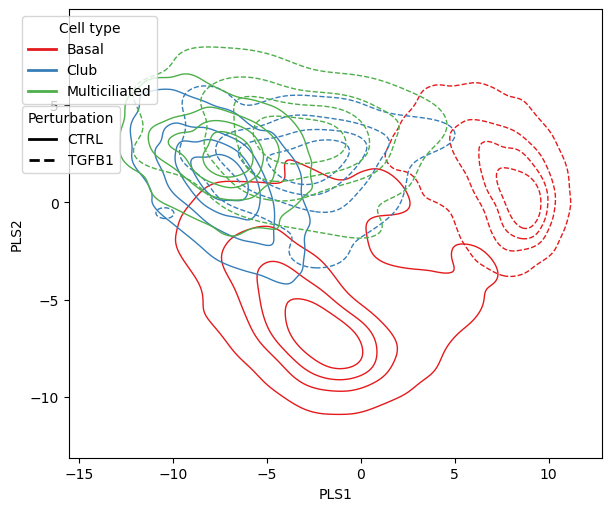

In [19]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout = True)

cats = sorted(X_pls_actual[cat_col].dropna().unique())
palette = dict(zip(cats, sns.color_palette('Set1', n_colors=len(cats))))
linestyle_map = {
    ctrl_pert: '-',
    'TGFB1': '--',
}

# KDE plots
for cat in cats:
    for pert in [ctrl_pert, 'TGFB1']:
        df_sub = X_pls_actual[
            (X_pls_actual[cat_col] == cat) &
            (X_pls_actual[pert_col] == pert)
        ]
        
        if len(df_sub) < 5:
            continue

        sns.kdeplot(
            data=df_sub,
            x='PLS1',
            y='PLS2',
            fill=False,
            levels=5,
            thresh=0.05,
            color=palette[cat],
            linestyles=linestyle_map[pert],
            linewidths=1,
            ax=ax,
        )

ax.set_xlabel('PLS1')
ax.set_ylabel('PLS2')

# ---- Manual legend ----

# color legend (cell types)
color_handles = [
    mlines.Line2D([], [], color=palette[cat], lw=2, label=cat)
    for cat in cats
]

# linestyle legend (perturbation)
style_handles = [
    mlines.Line2D([], [], color='black', linestyle=linestyle_map[p], lw=2, label=p)
    for p in [ctrl_pert, 'TGFB1']
]

legend1 = ax.legend(
    handles=color_handles,
    title='Cell type',
    bbox_to_anchor=(-0.1, 1),
    loc='upper left'
)

ax.add_artist(legend1)

ax.legend(
    handles=style_handles,
    title='Perturbation',
    bbox_to_anchor=(-0.1, 0.8),
    loc='upper left'
)

In [18]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True, constrained_layout=True)

# cats = sorted(X_pls_actual[cat_col].dropna().unique())
# palette = dict(zip(cats, sns.color_palette('Set1', n_colors=len(cats))))
# linestyle_map = {
#     ctrl_pert: '-',
#     'TGFB1': '--',
# }

# for ax, X_pls, title in zip(axes, [X_pls_actual, X_pls_pred], ['Actual', 'Predicted']):
    
#     for cat in cats:
#         for pert in [ctrl_pert, 'TGFB1']:
#             df_sub = X_pls[
#                 (X_pls[cat_col] == cat) &
#                 (X_pls[pert_col] == pert)
#             ]
            
#             if len(df_sub) < 5:
#                 continue

#             sns.kdeplot(
#                 data=df_sub,
#                 x='PLS1',
#                 y='PLS2',
#                 fill=False,
#                 levels=5,
#                 thresh=0.05,
#                 color=palette[cat],
#                 linestyles=linestyle_map[pert],
#                 linewidths=1,
#                 ax=ax,
#             )
    
#     ax.set_title(title)
#     ax.set_xlabel('PLS1')

# axes[0].set_ylabel('PLS2')
# axes[1].set_ylabel('')

# # ---- Manual legend ----

# # color legend (cell types)
# color_handles = [
#     mlines.Line2D([], [], color=palette[cat], lw=2, label=cat)
#     for cat in cats
# ]

# # linestyle legend (perturbation)
# style_handles = [
#     mlines.Line2D([], [], color='black', linestyle=linestyle_map[p], lw=2, label=p)
#     for p in [ctrl_pert, 'TGFB1']
# ]

# legend1 = fig.legend(
#     handles=color_handles,
#     title='Cell type',
#     bbox_to_anchor=(-0.1, 1),
#     loc='upper left'
# )

# fig.add_artist(legend1)

# fig.legend(
#     handles=style_handles,
#     title='Perturbation',
#     bbox_to_anchor=(-0.1, 0.8),  
#     loc='upper left'
# )

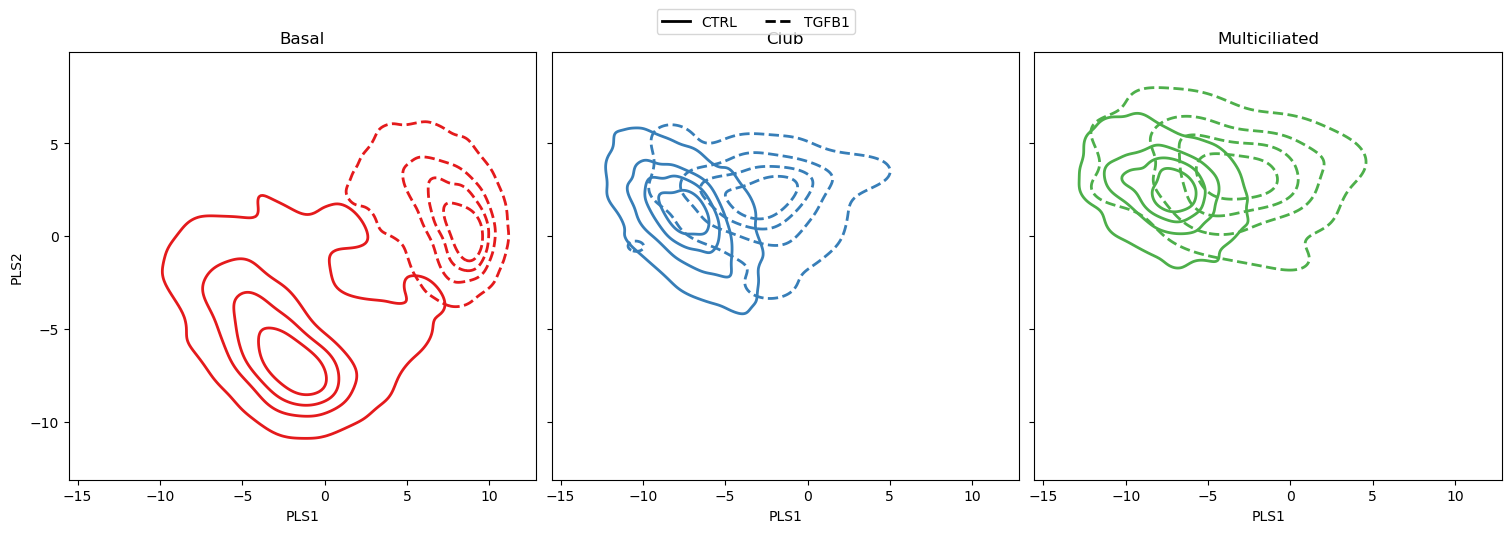

In [58]:
import matplotlib.lines as mlines

# grab limits from your existing plot
xlim = ax.get_xlim()
ylim = ax.get_ylim()

cats = sorted(X_pls_actual[cat_col].dropna().unique())
ncols = len(cats)

fig, axes = plt.subplots(
    1, ncols,
    figsize=(5*ncols, 5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)
axes = np.atleast_1d(axes)

palette = dict(zip(cats, sns.color_palette('Set1', n_colors=len(cats))))
linestyle_map = {
    ctrl_pert: '-',
    'TGFB1': '--',
}

for j, cat in enumerate(cats):
    ax_j = axes[j]
    
    for pert in [ctrl_pert, 'TGFB1']:
        df_sub = X_pls_actual[
            (X_pls_actual[cat_col] == cat) &
            (X_pls_actual[pert_col] == pert)
        ]
        
        if len(df_sub) < 5:
            continue

        sns.kdeplot(
            data=df_sub,
            x='PLS1',
            y='PLS2',
            fill=False,
            levels=5,
            thresh=0.05,
            color=palette[cat],
            linestyles=linestyle_map[pert],
            linewidths=2,
            ax=ax_j,
        )
    
    ax_j.set_title(cat)
    ax_j.set_xlim(xlim)
    ax_j.set_ylim(ylim)

# ---- manual perturbation legend ----
style_handles = [
    mlines.Line2D([], [], color='black', linestyle=linestyle_map[p], lw=2, label=p)
    for p in [ctrl_pert, 'TGFB1']
]

fig.legend(
    style_handles,
    [h.get_label() for h in style_handles],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=2
)

In [57]:
# # grab limits from your existing plot
# xlim = ax.get_xlim()
# ylim = ax.get_ylim()

# cats = sorted(X_pls_actual[cat_col].dropna().unique())
# ncols = len(cats)

# fig, axes = plt.subplots(
#     2, ncols,
#     figsize=(5*ncols, 10),
#     sharex=True,
#     sharey=True,
#     constrained_layout=True
# )

# palette = dict(zip(cats, sns.color_palette('Set1', n_colors=len(cats))))
# linestyle_map = {
#     ctrl_pert: '-',
#     'TGFB1': '--',
# }

# # loop over rows: 0 = actual, 1 = predicted
# for i, X_pls in enumerate([X_pls_actual, X_pls_pred]):
    
#     for j, cat in enumerate(cats):
#         ax_j = axes[i, j]
        
#         for pert in [ctrl_pert, 'TGFB1']:
#             df_sub = X_pls[
#                 (X_pls[cat_col] == cat) &
#                 (X_pls[pert_col] == pert)
#             ]
            
#             if len(df_sub) < 5:
#                 continue

#             sns.kdeplot(
#                 data=df_sub,
#                 x='PLS1',
#                 y='PLS2',
#                 fill=False,
#                 levels=5,
#                 thresh=0.05,
#                 color=palette[cat],
#                 linestyles=linestyle_map[pert],
#                 linewidths=2,
#                 ax=ax_j,
#             )
        
#         if i == 0:
#             ax_j.set_title(cat)
        
#         ax_j.set_xlim(xlim)
#         ax_j.set_ylim(ylim)

# # ---- right-side row labels (robust via twinx) ----
# ax_right_top = axes[0, -1].twinx()
# ax_right_top.set_ylabel('Actual', rotation=270, labelpad=25)
# ax_right_top.set_yticks([])
# ax_right_top.spines['right'].set_visible(False)

# ax_right_bottom = axes[1, -1].twinx()
# ax_right_bottom.set_ylabel('Predicted', rotation=270, labelpad=25)
# ax_right_bottom.set_yticks([])
# ax_right_bottom.spines['right'].set_visible(False)

# # ---- manual perturbation legend ----
# style_handles = [
#     mlines.Line2D([], [], color='black', linestyle=linestyle_map[p], lw=2, label=p)
#     for p in [ctrl_pert, 'TGFB1']
# ]

# fig.legend(
#     style_handles,
#     [h.get_label() for h in style_handles],
#     loc='upper center',
#     bbox_to_anchor=(0.5, 1.05),
#     ncol=2
# )

Visually, it does appear that TGFB1 has a much stronger effect in Basal cells than in Club and Multiciliated for the actual data.

In the predicted, though, unfortunately, it appears to have the weakest perturbation strength..see below


In [34]:
def get_distances(X: pd.DataFrame) -> pd.DataFrame:
    """
    For each unique label in `cat_col`, calculate the Mahalanobis and Euclidean
    centroid distances between 'TGFB1' and 'ctrl_pert' cells using PLS component columns.

    Parameters
    ----------
    X : pd.DataFrame
        DataFrame with PLS component columns plus `cat_col` and `pert_col`.
        `pert_col` contains 'TGFB1' or 'ctrl_pert'.

    Returns
    -------
    pd.DataFrame
        Mahalanobis and Euclidean centroid distances per unique category in `cat_col`.
    """
    pls_cols = [c for c in X.columns if c.startswith('PLS')]
    results = {}

    for cat, group in X.groupby(cat_col):
        ctrl = group.loc[group[pert_col] == ctrl_pert, pls_cols]
        tgfb = group.loc[group[pert_col] == "TGFB1",   pls_cols]

        if ctrl.empty or tgfb.empty:
            results[cat] = {"mahalanobis_distance": np.nan, "euclidean_distance": np.nan}
            continue

        mean_ctrl = ctrl.mean().values
        mean_tgfb = tgfb.mean().values

        # Mahalanobis — covariance from ctrl cells, fall back to identity if singular
        cov = ctrl.cov().values
        try:
            VI = inv(cov)
        except np.linalg.LinAlgError:
            VI = np.eye(cov.shape[0])

        results[cat] = {
            "mahalanobis_distance": mahalanobis(mean_tgfb, mean_ctrl, VI),
            "euclidean_distance":   np.linalg.norm(mean_tgfb - mean_ctrl),
        }

    return pd.DataFrame(results).T.rename_axis(cat_col)

In [35]:
get_distances(X_pls_pred)

,mahalanobis_distance,euclidean_distance
cell_type,,
Basal,1.386162,3.134940
Club,5.753948,7.803486
Multiciliated,4.499391,6.656781


In [59]:
dist_actual = get_distances(X_pls_actual)
dist_actual['type'] = 'actual'
dist_pred = get_distances(X_pls_pred) # averages across ensembles, but could do separately for each, result is same
dist_pred['type'] = 'predicted'
pd.concat([dist_actual, dist_pred], ignore_index = False)

,mahalanobis_distance,euclidean_distance,type
cell_type,,,
Basal,6.253770,11.770264,actual
Club,4.481218,6.039908,actual
Multiciliated,3.347997,4.587602,actual
Basal,1.386162,3.134940,predicted
Club,5.753948,7.803486,predicted
Multiciliated,4.499391,6.656781,predicted
